# CPTR 330 - In-Class Code: Image and Video Compression Basics

1. **Lossy image compression** with JPEG quality settings  
2. **Lossless compression intuition** with a simple Run-Length Encoding (RLE) example  
3. **Temporal redundancy in video** using frame differencing  

## Learning Goals

By the end of this notebook, students should be able to:

- Explain the trade-off between **file size** and **visual quality**
- Observe how **JPEG quality** affects compression
- Understand why **RLE works better on simple images** than on photographs
- See how video compression benefits from **small changes between consecutive frames**

## Recommended Libraries

This notebook uses:

- `Pillow` for image reading/saving
- `numpy` for array manipulation
- `matplotlib` for visualization
- `opencv-python` (`cv2`) for video reading

If needed, uncomment the installation line below.

In [1]:
# Uncomment if you need to install dependencies inside Jupyter:
# !pip install pillow opencv-python matplotlib numpy

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

## Folder Setup

Place your files in the same folder as this notebook, or update the paths below.

Suggested files:

- `photo.jpg` -> a natural photograph
- `simple.png` -> a simple graphic, icon, logo, or drawing
- `sample_video.mp4` -> a short video clip

If you do not have these files yet, you can still run the notebook sections one by one after updating the paths.

In [57]:
SIMPLE_IMAGE_PATH = "images/lego.png"
PHOTO_PATH = "images/screenshot.png"
VIDEO_PATH = "images/lowmot.mkv"

OUTPUT_DIR = Path("compression_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: /home/lev/dev/anaconda/compression_outputs


# Part 1 - JPEG Quality vs File Size

JPEG is a **lossy** compression format.  
That means some information is discarded to reduce file size.

In this activity, we will:

- load an image
- save it multiple times using different JPEG quality settings
- compare file sizes
- inspect the visual differences

In [31]:
def load_image_rgb(path):
    img = Image.open(path).convert("RGB")
    return img

def save_jpeg_versions(img, output_dir, qualities=(95, 75, 50, 20)):
    saved_files = []
    for q in qualities:
        out_path = output_dir / f"photo_q{q}.jpg"
        img.save(out_path, format="JPEG", quality=q)
        saved_files.append((q, out_path))
    return saved_files

def file_size_kb(path):
    return os.path.getsize(path) / 1024

if os.path.exists(PHOTO_PATH):
    photo = load_image_rgb(PHOTO_PATH)
    jpeg_versions = save_jpeg_versions(photo, OUTPUT_DIR)
    for q, p in jpeg_versions:
        print(f"Quality {q}: {p.name} -> {file_size_kb(p):.2f} KB")
else:
    print(f"File not found: {PHOTO_PATH}")

Quality 95: photo_q95.jpg -> 181.38 KB
Quality 75: photo_q75.jpg -> 88.69 KB
Quality 50: photo_q50.jpg -> 63.57 KB
Quality 20: photo_q20.jpg -> 39.91 KB


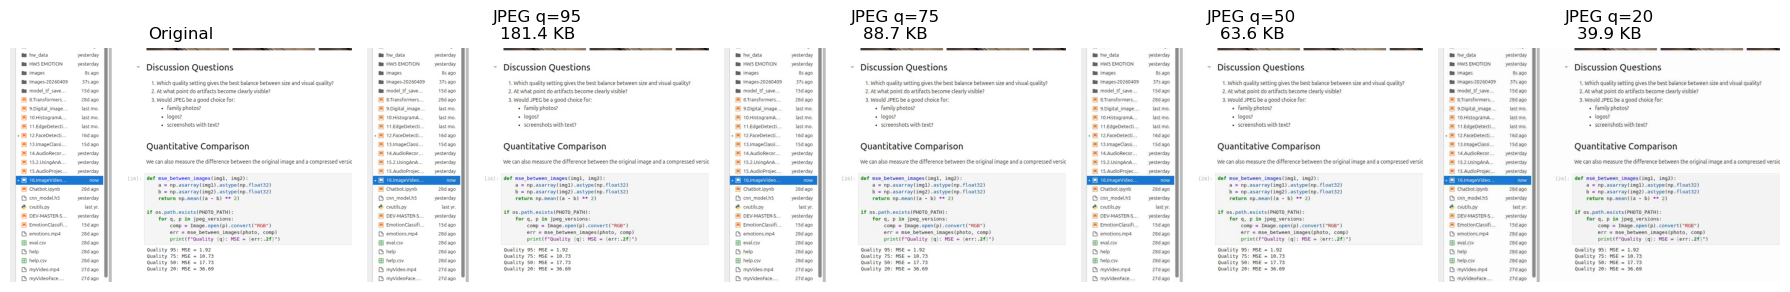

In [32]:
if os.path.exists(PHOTO_PATH):
    fig, axes = plt.subplots(1, len(jpeg_versions) + 1, figsize=(18, 5))

    axes[0].imshow(photo)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for ax, (q, p) in zip(axes[1:], jpeg_versions):
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(f"JPEG q={q}\n{file_size_kb(p):.1f} KB")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Discussion Questions

1. Which quality setting gives the best balance between size and visual quality?
2. At what point do artifacts become clearly visible?
3. Would JPEG be a good choice for:
   - family photos?
   - logos?
   - screenshots with text?

## Quantitative Comparison

We can also measure the difference between the original image and a compressed version using a simple metric such as **Mean Squared Error (MSE)**.

In [24]:
def mse_between_images(img1, img2):
    a = np.asarray(img1).astype(np.float32)
    b = np.asarray(img2).astype(np.float32)
    return np.mean((a - b) ** 2)

if os.path.exists(PHOTO_PATH):
    for q, p in jpeg_versions:
        comp = Image.open(p).convert("RGB")
        err = mse_between_images(photo, comp)
        print(f"Quality {q}: MSE = {err:.2f}")

Quality 95: MSE = 1.92
Quality 75: MSE = 10.73
Quality 50: MSE = 17.73
Quality 20: MSE = 36.69


# Part 2 - Simple Run-Length Encoding (RLE)

RLE is a **lossless** idea that works well when data contains long runs of repeated values.

For example, instead of storing:

`0, 0, 0, 0, 0, 1, 1, 1`

we can store:

`(0,5), (1,3)`

This is especially effective for:

- icons
- simple drawings
- binary masks
- images with large flat regions

It is usually **not very effective for photographs**.

## Step 1 - Create a Binary Version of an Image

To keep the activity simple, we convert an image to grayscale and then to a binary image.

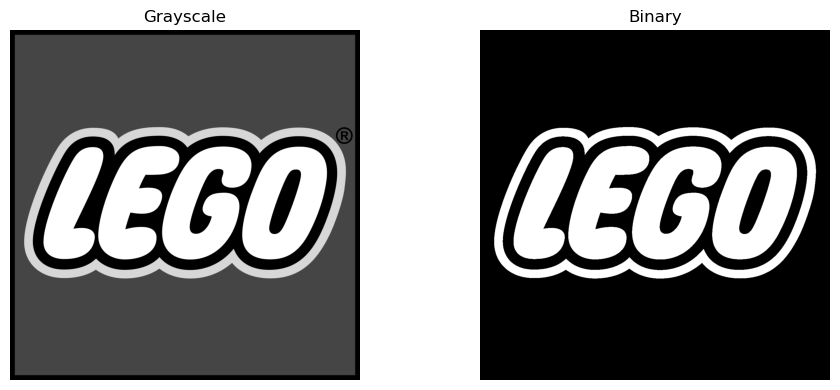

In [33]:
def image_to_binary_array(path, threshold=128):
    img = Image.open(path).convert("L")
    arr = np.array(img)
    binary = (arr >= threshold).astype(np.uint8)
    return img, binary

if os.path.exists(SIMPLE_IMAGE_PATH):
    gray_img, binary_img = image_to_binary_array(SIMPLE_IMAGE_PATH, threshold=128)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(gray_img, cmap="gray")
    axes[0].set_title("Grayscale")
    axes[0].axis("off")

    axes[1].imshow(binary_img, cmap="gray")
    axes[1].set_title("Binary")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"File not found: {SIMPLE_IMAGE_PATH}")

## Step 2 - Implement Basic RLE for One Row

In [34]:
def rle_encode_1d(arr):
    if len(arr) == 0:
        return []

    encoded = []
    current_value = arr[0]
    count = 1

    for x in arr[1:]:
        if x == current_value:
            count += 1
        else:
            encoded.append((int(current_value), count))
            current_value = x
            count = 1

    encoded.append((int(current_value), count))
    return encoded

# Demonstrate RLE on a sample array
example = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1], dtype=np.uint8)
print("Original:", example.tolist())
print("RLE:", rle_encode_1d(example))

Original: [0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1]
RLE: [(0, 3), (1, 2), (0, 2), (1, 4)]


## Step 3 - Apply RLE Row by Row to a Binary Image

In [35]:
def rle_encode_2d(binary_array):
    return [rle_encode_1d(row) for row in binary_array]

def approximate_rle_size(encoded_rows):
    # Estimate two stored values per run: value and count
    total_runs = sum(len(row) for row in encoded_rows)
    return total_runs * 2

if os.path.exists(SIMPLE_IMAGE_PATH):
    encoded_rows = rle_encode_2d(binary_img)

    original_size = binary_img.size  # Total number of pixels
    rle_size = approximate_rle_size(encoded_rows)

    print(f"Original binary image size (values stored): {original_size}")
    print(f"Approximate RLE size (value,count pairs): {rle_size}")
    print(f"Approximate compression ratio: {original_size / rle_size:.2f}")

Original binary image size (values stored): 1638400
Approximate RLE size (value,count pairs): 17524
Approximate compression ratio: 93.49


## Compare RLE on a Simple Image vs a Photograph

This is the key idea: RLE usually performs better on **simple structured images** than on **natural photos**.

In [36]:
def compare_rle_on_image(path, threshold=128):
    gray, binary = image_to_binary_array(path, threshold)
    encoded = rle_encode_2d(binary)
    original_size = binary.size
    rle_size = approximate_rle_size(encoded)
    ratio = original_size / rle_size if rle_size > 0 else np.nan
    return gray, binary, original_size, rle_size, ratio

results = []

if os.path.exists(SIMPLE_IMAGE_PATH):
    _, _, orig_s, rle_s, ratio_s = compare_rle_on_image(SIMPLE_IMAGE_PATH)
    results.append(("Simple image", orig_s, rle_s, ratio_s))

if os.path.exists(PHOTO_PATH):
    _, _, orig_p, rle_p, ratio_p = compare_rle_on_image(PHOTO_PATH)
    results.append(("Photograph", orig_p, rle_p, ratio_p))

for name, orig, rle, ratio in results:
    print(f"{name}: original={orig}, approx_rle={rle}, ratio={ratio:.2f}")

Simple image: original=1638400, approx_rle=17524, ratio=93.49
Photograph: original=581151, approx_rle=48778, ratio=11.91


## Discussion Questions

1. Why does RLE usually work better for icons and drawings?
2. Why is it weaker for photographs?
3. Is this RLE size estimate exact? Why or why not?

# Part 3 - Video Compression Intuition with Frame Differencing

A major idea in video compression is **temporal redundancy**:

- consecutive frames are often very similar
- instead of storing every frame fully, we can store only changes

Here we simulate that idea with **frame differencing**.

In [59]:
def read_first_n_frames(video_path, n=5):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < n:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()
    return frames

if os.path.exists(VIDEO_PATH):
    frames = read_first_n_frames(VIDEO_PATH, n=25)
    print(f"Frames loaded: {len(frames)}")
else:
    print(f"File not found: {VIDEO_PATH}")

Frames loaded: 25


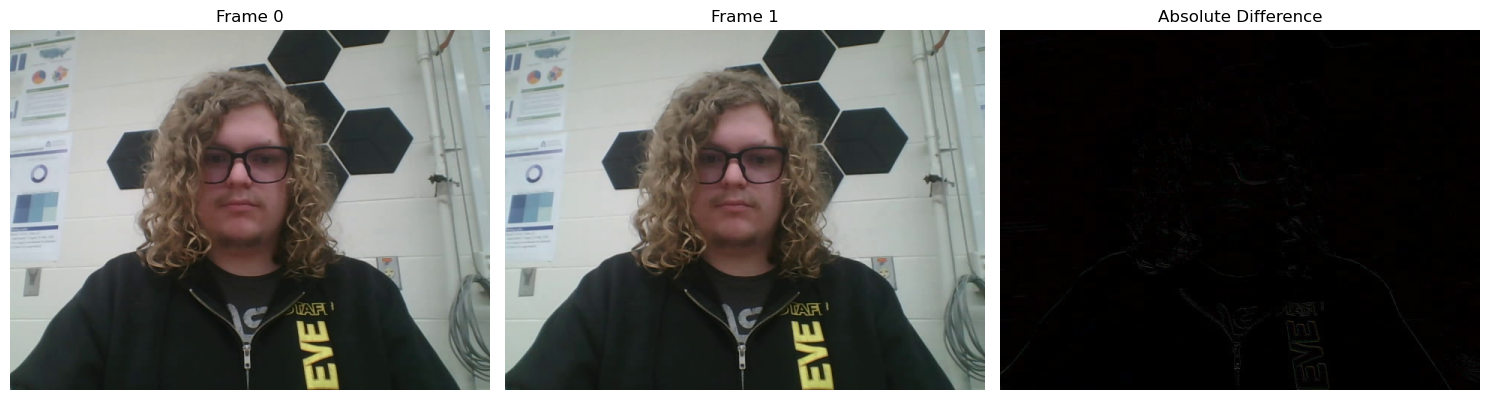

In [60]:
def frame_difference(frame_a, frame_b):
    diff = np.abs(frame_b.astype(np.int16) - frame_a.astype(np.int16)).astype(np.uint8)
    return diff

firstFrame = 0
secondFrame = 1

if os.path.exists(VIDEO_PATH) and len(frames) >= 2:
    diff_01 = frame_difference(frames[firstFrame], frames[secondFrame])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(frames[firstFrame])
    axes[0].set_title(f"Frame {firstFrame}")
    axes[0].axis("off")

    axes[1].imshow(frames[secondFrame])
    axes[1].set_title(f"Frame {secondFrame}")
    axes[1].axis("off")

    axes[2].imshow(diff_01)
    axes[2].set_title("Absolute Difference")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Measure How Much Changes Between Frames

In [61]:
def mean_absolute_difference(frame_a, frame_b):
    return np.mean(np.abs(frame_b.astype(np.float32) - frame_a.astype(np.float32)))

if os.path.exists(VIDEO_PATH) and len(frames) >= 2:
    for i in range(len(frames) - 1):
        mad = mean_absolute_difference(frames[i], frames[i + 1])
        print(f"Frame {i} -> Frame {i+1}: mean absolute difference = {mad:.2f}")

Frame 0 -> Frame 1: mean absolute difference = 1.46
Frame 1 -> Frame 2: mean absolute difference = 0.03
Frame 2 -> Frame 3: mean absolute difference = 0.01
Frame 3 -> Frame 4: mean absolute difference = 0.00
Frame 4 -> Frame 5: mean absolute difference = 0.00
Frame 5 -> Frame 6: mean absolute difference = 0.00
Frame 6 -> Frame 7: mean absolute difference = 0.00
Frame 7 -> Frame 8: mean absolute difference = 0.00
Frame 8 -> Frame 9: mean absolute difference = 0.00
Frame 9 -> Frame 10: mean absolute difference = 0.86
Frame 10 -> Frame 11: mean absolute difference = 0.05
Frame 11 -> Frame 12: mean absolute difference = 1.04
Frame 12 -> Frame 13: mean absolute difference = 1.27
Frame 13 -> Frame 14: mean absolute difference = 0.02
Frame 14 -> Frame 15: mean absolute difference = 0.98
Frame 15 -> Frame 16: mean absolute difference = 0.47
Frame 16 -> Frame 17: mean absolute difference = 0.04
Frame 17 -> Frame 18: mean absolute difference = 0.86
Frame 18 -> Frame 19: mean absolute difference 

# Exercises

## Exercise 1
Repeat the JPEG quality experiment with another photograph.  
Which image compresses better?

#### Given Image:
Quality 95: MSE = 0.43
Quality 75: MSE = 0.05
Quality 50: MSE = 19.76
Quality 20: MSE = 45.22

#### My Image:
Quality 95: MSE = 1.92
Quality 75: MSE = 10.73
Quality 50: MSE = 17.73
Quality 20: MSE = 36.69

#### Answer:
My image compressed better as it had less error. (some of this may be due to it already being a jpg)

## Exercise 2
Test RLE on:
- a logo
- a screenshot with text
- a natural photo

Which one gives the best approximate compression ratio?

Simple image: original=1638400, approx_rle=17524, ratio=93.49
Photograph: original=12000000, approx_rle=381716, ratio=31.44
Screenshot(Text): original=581151, approx_rle=48778, ratio=11.91

The simple image (Lego Logo) gave the best compression ratio and the text image was worst.

## Exercise 3
Use a different video:
- one with very little motion
- one with lots of motion

How does movement affect frame differences?

#### Low Motion Video Results:
- Frame 0 -> Frame 1: mean absolute difference = 1.46
- Frame 1 -> Frame 2: mean absolute difference = 0.03
- Frame 2 -> Frame 3: mean absolute difference = 0.01
- Frame 3 -> Frame 4: mean absolute difference = 0.00
- Frame 4 -> Frame 5: mean absolute difference = 0.00
- Frame 5 -> Frame 6: mean absolute difference = 0.00
- Frame 6 -> Frame 7: mean absolute difference = 0.00
- Frame 7 -> Frame 8: mean absolute difference = 0.00
- Frame 8 -> Frame 9: mean absolute difference = 0.00
- Frame 9 -> Frame 10: mean absolute difference = 0.86
- Frame 10 -> Frame 11: mean absolute difference = 0.05
- Frame 11 -> Frame 12: mean absolute difference = 1.04
- Frame 12 -> Frame 13: mean absolute difference = 1.27
- Frame 13 -> Frame 14: mean absolute difference = 0.02
- Frame 14 -> Frame 15: mean absolute difference = 0.98
- Frame 15 -> Frame 16: mean absolute difference = 0.47
- Frame 16 -> Frame 17: mean absolute difference = 0.04
- Frame 17 -> Frame 18: mean absolute difference = 0.86
- Frame 18 -> Frame 19: mean absolute difference = 0.81
- Frame 19 -> Frame 20: mean absolute difference = 0.02
- Frame 20 -> Frame 21: mean absolute difference = 0.56
- Frame 21 -> Frame 22: mean absolute difference = 1.00
- Frame 22 -> Frame 23: mean absolute difference = 0.02
- Frame 23 -> Frame 24: mean absolute difference = 0.22


#### High Motion Video Results:
- Frame 0 -> Frame 1: mean absolute difference = 31.26
- Frame 1 -> Frame 2: mean absolute difference = 0.05
- Frame 2 -> Frame 3: mean absolute difference = 0.01
- Frame 3 -> Frame 4: mean absolute difference = 0.00
- Frame 4 -> Frame 5: mean absolute difference = 0.00
- Frame 5 -> Frame 6: mean absolute difference = 0.00
- Frame 6 -> Frame 7: mean absolute difference = 0.00
- Frame 7 -> Frame 8: mean absolute difference = 0.00
- Frame 8 -> Frame 9: mean absolute difference = 0.00
- Frame 9 -> Frame 10: mean absolute difference = 16.18
- Frame 10 -> Frame 11: mean absolute difference = 18.54
- Frame 11 -> Frame 12: mean absolute difference = 19.67
- Frame 12 -> Frame 13: mean absolute difference = 11.75
- Frame 13 -> Frame 14: mean absolute difference = 17.07
- Frame 14 -> Frame 15: mean absolute difference = 25.66
- Frame 15 -> Frame 16: mean absolute difference = 23.61
- Frame 16 -> Frame 17: mean absolute difference = 13.00
- Frame 17 -> Frame 18: mean absolute difference = 21.31
- Frame 18 -> Frame 19: mean absolute difference = 20.29
- Frame 19 -> Frame 20: mean absolute difference = 19.63
- Frame 20 -> Frame 21: mean absolute difference = 19.25
- Frame 21 -> Frame 22: mean absolute difference = 18.23
- Frame 22 -> Frame 23: mean absolute difference = 9.88
- Frame 23 -> Frame 24: mean absolute difference = 13.29


More movement results in higher differences between frames.



## Exercise 4
Write a short paragraph explaining:

- when lossless compression is preferable
- when lossy compression is acceptable
- why video compression benefits from temporal redundancy

Losless compression is preferable in professional photography or in applications such as satelite and medical imaging where the finest of details is highly important. Lossy compression is acceptable in applications where high detail is not needed such as cartoons, company logos, thumbnails for videos or previewing images, and applications where storage matters more than fidelity. Video compressions use of temporal redundancy helps save on transmission and storage data demands, as many frames maintain the same background with only small regions containing movement. This is especially true in many cartoons, as the background is fixed and characters are moving slightly across the scene.